<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Clustering_Jerarquico_para_datos_de_comportamiento_de_compras_de_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

Se trata del conjunto de datos con mil registros con cuatro variables numéricas y cuatro variables categóricas. Se hace una implementación de modelo de clustering mediante modelo *K-Prototypes* dada la existencia de variables numéricas y categóricas.

Las variables numéricas del conjunto de datos son:

* *edad* años cumplidos del cliente,
* *ingreso* que representa precisamente el ingreso económico comprobado del cliente;
* *visitasmes* es la cantidad promedio de visitas que hace un cliente o que compra al mes;
* *gasto* es el monto económico que un cliente gasta al mes por concepto de compras.

Las variables categóricas son:           
* *canal* que es el medio por el cual un cliente adquiere los productos: *App*, *Tienda*, *Web* o *Telefono*;
* *region* la localización regional en donde se reporta que radica el cliente: *Centro*, *Norte*, *Occidente* o *Sur*;
* *satisfaccion* el nivel de satisfacción en las compras del cliente: *Alta*, *Media* o *Baja*;
* *promocion"* El nivel de respuesta que el cliente tiene ante promociones: *Alta*, *Media* o *Baja*.

Luego, el conjunto de datos contiene dos variables que son descartadas para el modelo como *id* y *perfil_simulado* no considerados para los modelos.

El documento se puede encontrar en https://colab.research.google.com/drive/1Ct771ZWWJIqqCy8Xg0VvxfEMZYuQB6pT?usp=sharing .

Tambien puede encontrarse en la plataforma *github.com* en https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Clustering_Jerarquico_para_datos_de_comportamiento_de_compras_de_clientes.ipynb .

Los datos pueden descargarse desde el servicio *github.com* en https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_clientes_kprototypes_1000.csv .

Las funciones puede encontrase en https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20Clustering%20Jer%C3%A1rquico.py .




# Objetivo

Implementar y evaluar modelo *Clustering Jerárquico* para dos y tres clústeres para datos de comportamiento de compras de clientes.


# Descripción

## Cargar librerías

In [1]:
!pip install gower

In [2]:
import numpy as np   # Para estructuras de datos
import pandas as pd  # Cargar conjuntos de datos
import matplotlib.pyplot as plt # Visualizar
import math # Funciones matemáticas
import itertools # Para iteraciones o ciclos
import seaborn as sns   # Gráficos

import matplotlib.pyplot as plt

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet

from sklearn.metrics import silhouette_score

import gower




## Cargar funciones


In [3]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20Clustering%20Jer%C3%A1rquico.py"
import requests

exec(requests.get(url).text)

## Cargar datos

Con la función *f_cargar_datos()* se cargan los datos originales y solo se seleccionas las variables de interés *edad*, *ingreso*, *visitasmes*, *gasto*, *canal*, *region*, *satisfaccion* y *promocion*.

Con la función *f_visualizar_head_tail_reducido()* se presentan los primeros y últimos registros.


In [4]:
datos = f_cargar_datos("https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_clientes_kprototypes_1000.csv")
datos = datos[["id", "edad", "ingreso", "visitasmes", "gasto", "canal", "region", "satisfaccion","promocion"]]

f_visualizar_head_tail_reducido(datos)

,id,edad,ingreso,visitasmes,...,canal,region,satisfaccion,promocion
0,C0001,37,27314,6,...,App,Centro,Baja,Alta
1,C0002,33,20752,5,...,Tienda,Norte,Alta,Baja
2,C0003,58,18618,7,...,Web,Occidente,Baja,Media
3,C0004,41,19504,4,...,Web,Centro,Alta,Media
4,C0005,22,28646,10,...,App,Occidente,Media,Media
5,C0006,43,42390,16,...,App,Norte,Alta,Media
6,...,...,...,...,...,...,...,...,...
7,C0995,42,24809,2,...,Telefono,Occidente,Baja,Baja
8,C0996,47,49053,18,...,App,Norte,Alta,Media
9,C0997,26,48145,20,...,Web,Norte,Media,Media


## Estadísticos descriptivos de variables numéricas

Se presentan los estadísticos descriptivos de las variables numéricas.


In [5]:
variables_numericas=["edad", "ingreso", "visitasmes", "gasto"]
f_describir_datos(datos[variables_numericas])

{'describe':              count       mean         std     min       25%      50%      75%  \
 edad        1000.0     37.779     11.1956    18.0     29.00     37.0     45.0   
 ingreso     1000.0  27185.342  11889.1230  5000.0  18648.75  24830.5  33903.0   
 visitasmes  1000.0      7.850      4.9279     0.0      4.00      7.0     11.0   
 gasto       1000.0   1592.775   1098.9411   100.0    769.50   1294.0   2159.0   
 
                 max  
 edad           75.0  
 ingreso     70936.0  
 visitasmes     22.0  
 gasto        5245.0  ,
 'frecuencias': {},
 'structure': edad          int64
 ingreso       int64
 visitasmes    int64
 gasto         int64
 dtype: object}

## Frecuencias de clases de variables categóricas

Se presentan las frecuencias de las variables categóricas *canal*, *region*, *satisfaccion* y *promocion* con la función *f_frecuencias_clases()*.

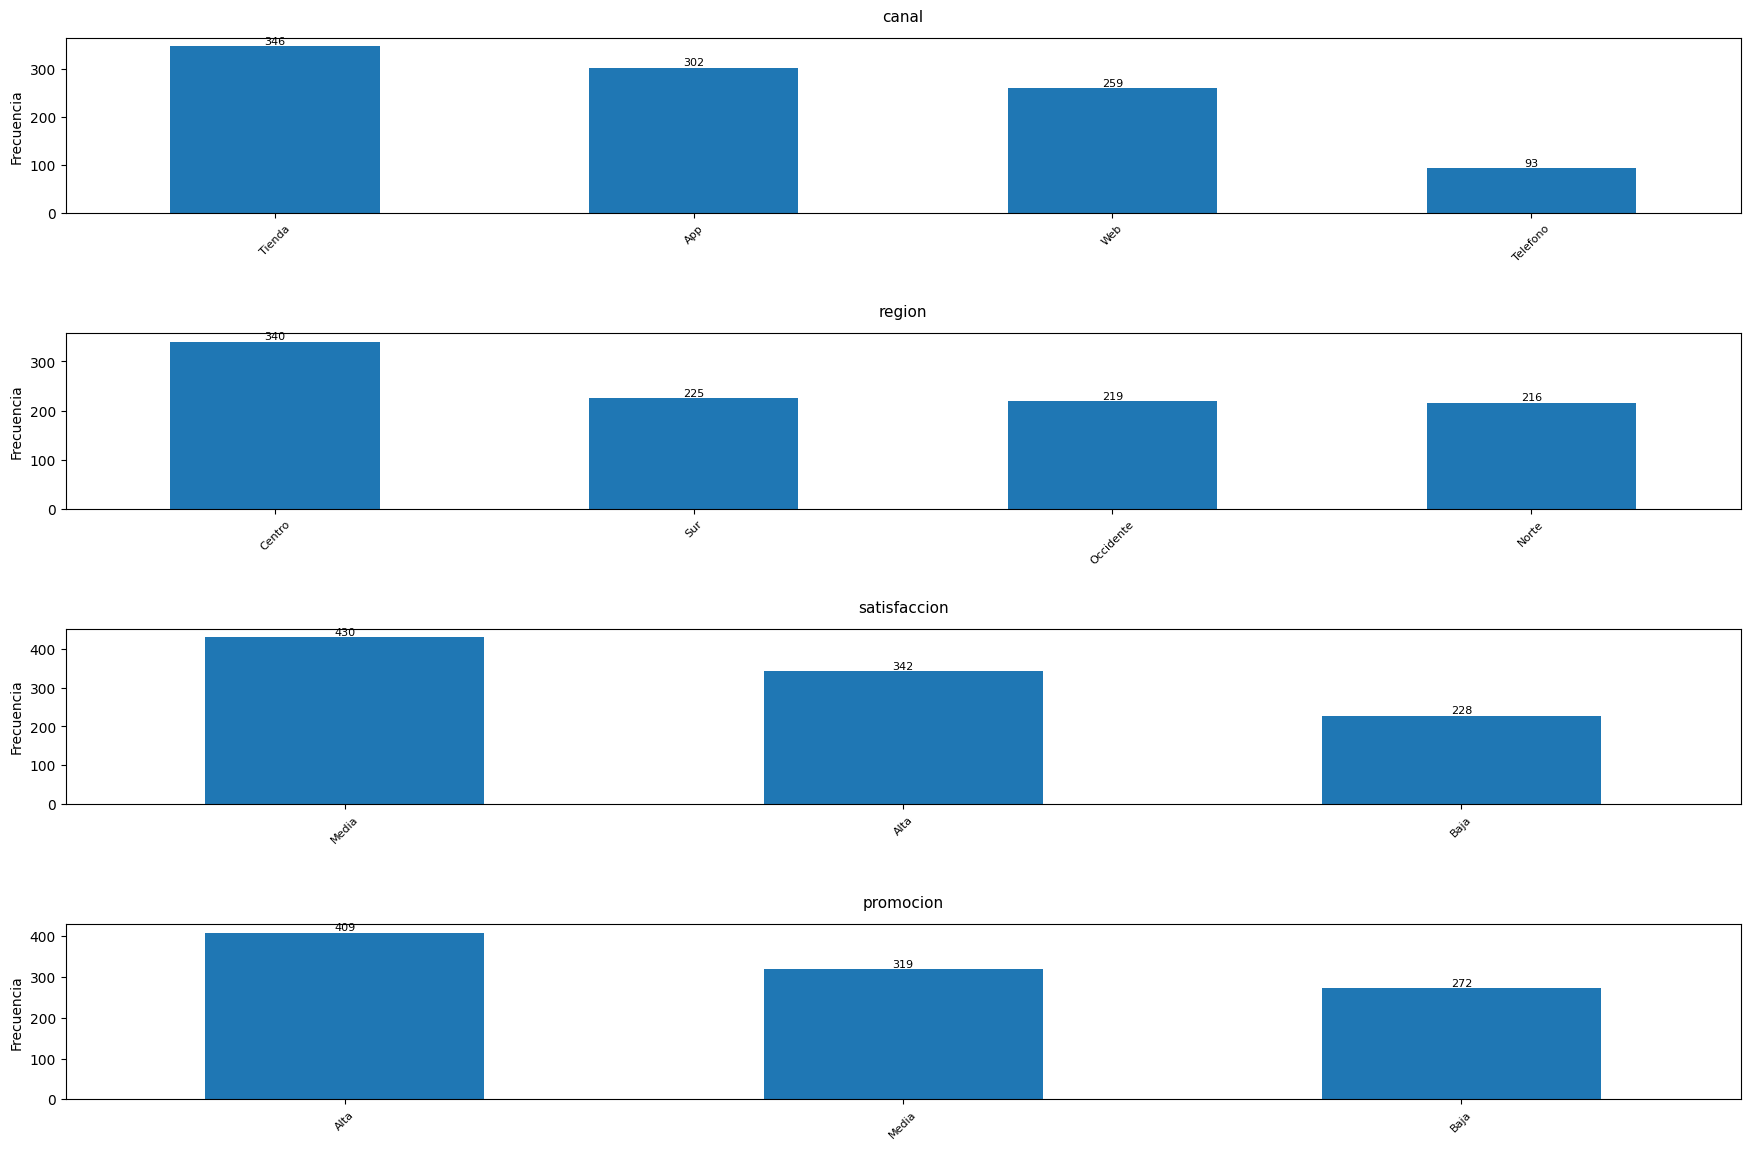

In [6]:
variables_categoricas=["canal", "region", "satisfaccion", "promocion"]
f_frecuencias_clases(datos[variables_categoricas])

# Desarrollo

Se construye el modelo  *Clustering Jerárquico* para *K=4* clústeres.

## Preparación de datos para el modelo

La función *f_preparar_datos_modelo()* permite organizar el conjunto de datos antes de aplicar clustering jerárquico. En esta etapa se definen las variables numéricas y categóricas que serán utilizadas por el modelo, se excluyen variables identificadoras o de referencia, y se construye un nuevo conjunto de datos con las variables seleccionadas.

La función valida que las variables existan en el conjunto original, convierte las variables categóricas a formato de texto y revisa la presencia de valores perdidos. De esta forma, se garantiza que los datos estén listos para el cálculo de la distancia de *Gowe* y la construcción posterior del modelo jerárquico.


In [7]:
# PREPARAR DATOS DEL MODELO
preparacion = f_preparar_datos_modelo(
    datos=datos,
    variables_numericas=variables_numericas,
    variables_categoricas=variables_categoricas,
    variable_id="id"
)


PREPARACIÓN DE DATOS PARA EL MODELO
Registros: 1000
Variables del modelo: 8
----------------------------------------
Variables numéricas:
['edad', 'ingreso', 'visitasmes', 'gasto']
----------------------------------------
Variables categóricas:
['canal', 'region', 'satisfaccion', 'promocion']
----------------------------------------
Variable ID: id
Valores perdidos totales: 0



Se construye con el modelo *Clustering Jerárquico* con cuatro clústeres y los argumentos que se envían a la función *f_crear_KPrototypes()*.  


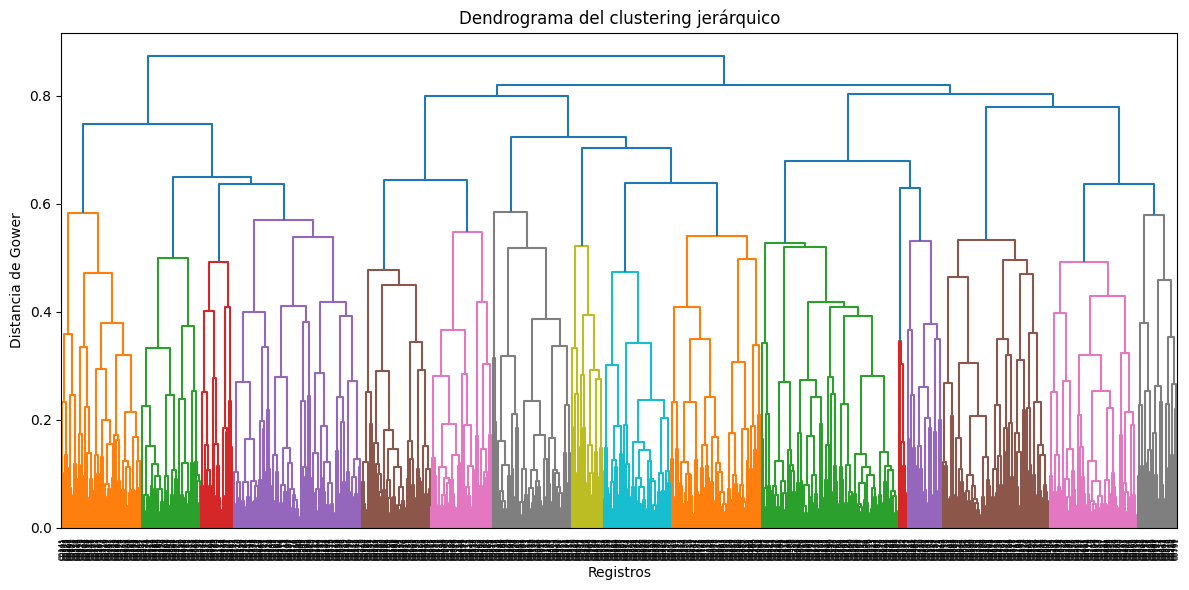


MODELO DE CLUSTERING JERÁRQUICO
Registros: 1000
Variables del modelo: 8
Distancia utilizada: Gower
Método de enlace: complete
Número de clústeres K: 4
----------------------------------------
Frecuencia por clúster:
 cluster  frecuencia  porcentaje
       1         269        26.9
       2         358        35.8
       3         162        16.2
       4         211        21.1



In [8]:
modelo_CJ = f_crear_modelo_clustering_jerarquico(
    datos=datos,
    datos_modelo=preparacion["datos_modelo"],
    datos_identificacion=preparacion["datos_identificacion"],
    variable_id=preparacion["variable_id"],
    k=4,
    metodo_enlace="complete",
    graficar=True
)

Al construir el dendograma, se generan visualmente muchas agrupaciones lo que dificulta su interpretación de cuales registros están asignados a cada clúster.

El haberle indicado *K=4* significa que se construyeron cuatro grupos de los cuales el *26.9%* corresponde al *clúster 1*; el *35.8%* al *clúster 2*; el *16.2%* de los registros corresponden al *clúster 3* y el *21.1%* de los registros al *clúster 4*.

Al final con el siguiente código el dendograma con un corte *K=4*.




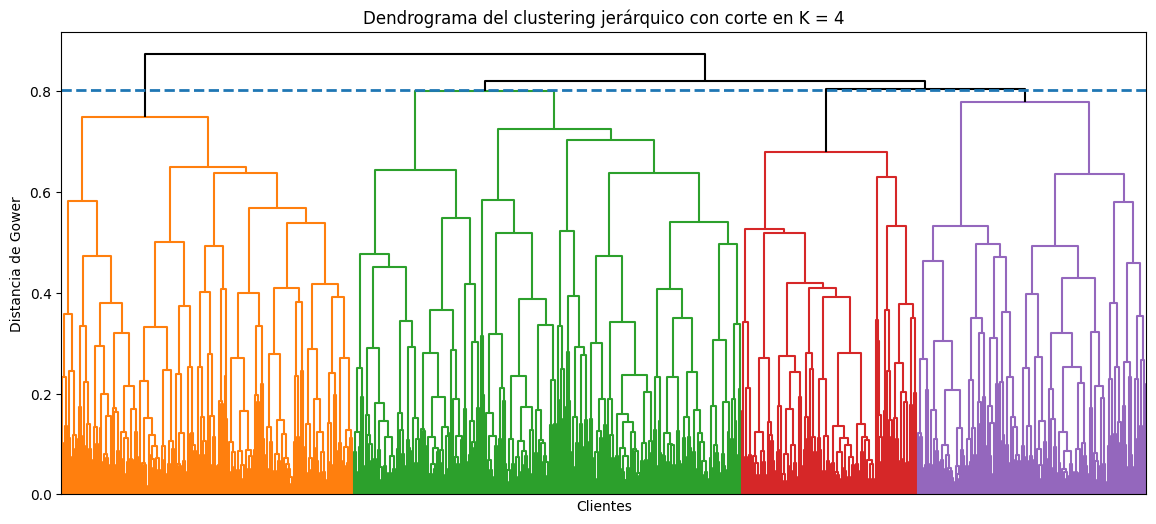

In [9]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

# K DESEADO

k = 4

modelo_hc = modelo_CJ["modelo_hc"]

# ALTURA DE CORTE PARA K CLÚSTERES

altura_corte = (
    modelo_hc[-k, 2] + modelo_hc[-k + 1, 2]
) / 2

# DENDROGRAMA CON CORTE EN K = 4

plt.figure(figsize=(14, 6))
dendrogram(
    modelo_hc,
    color_threshold=altura_corte,
    above_threshold_color="black",
    no_labels=True
)

plt.axhline(
    y=altura_corte,
    linestyle="--",
    linewidth=2
)

plt.title("Dendrograma del clustering jerárquico con corte en K = 4")
plt.xlabel("Clientes")
plt.ylabel("Distancia de Gower")
plt.show()

## Perfiles del modelo Clustering Jerárquico



In [10]:
perfiles_CJ = f_perfiles(
    modelo=modelo_CJ,
    variables_numericas=variables_numericas,
    variables_categoricas=variables_categoricas,
    variable_cluster="cluster",
    decimales=2
)


PERFILES DE CLÚSTERES
Número de registros: 1000
Variable de clúster: cluster
----------------------------------------
Variables numéricas:
['edad', 'ingreso', 'visitasmes', 'gasto']
----------------------------------------
Variables categóricas:
['canal', 'region', 'satisfaccion', 'promocion']
----------------------------------------
Frecuencia por clúster:
 cluster  frecuencia  porcentaje
       1         269        26.9
       2         358        35.8
       3         162        16.2
       4         211        21.1



In [11]:
# Perfil numérico
perfiles_CJ["perfil_numerico"]

,cluster,n,edad,ingreso,visitasmes,gasto
0,1,269,40.21,26402.29,7.17,1509.92
1,2,358,33.85,32559.27,10.62,2156.78
2,3,162,42.09,22630.73,4.90,1028.59
3,4,211,38.03,22562.69,6.28,1174.64


In [12]:
# Perfil categórico
perfiles_CJ["perfil_categorico"]

,cluster,canal_dominante,region_dominante,satisfaccion_dominante,promocion_dominante
0,1,Tienda,Sur,Alta,Media
1,2,App,Centro,Alta,Alta
2,3,Tienda,Centro,Media,Baja
3,4,Tienda,Centro,Baja,Alta


In [13]:
# Perfil general integrado
perfiles_CJ["perfil_general"]

,cluster,n,edad,ingreso,visitasmes,gasto,canal_dominante,region_dominante,satisfaccion_dominante,promocion_dominante
0,1,269,40.21,26402.29,7.17,1509.92,Tienda,Sur,Alta,Media
1,2,358,33.85,32559.27,10.62,2156.78,App,Centro,Alta,Alta
2,3,162,42.09,22630.73,4.90,1028.59,Tienda,Centro,Media,Baja
3,4,211,38.03,22562.69,6.28,1174.64,Tienda,Centro,Baja,Alta


### Dispersión de pares de variables numéricas K-Prototypes K=4

La visualización de la dispersión se hace con la función *f_dispersion_variables_clusters()*. La **grafica** muestra la relación entre variables numéricas por pares y los clústeres creados del modelo *Clustering Jerárquico* con *K=4, **se observa que el modelo separa a los clientes principalmente en función de variables asociadas con el valor comercial**.





## Interpretación de perfiles

*Clúster 1*: clientes presenciales satisfechos con consumo medio

El clúster *1* agrupa a *269* clientes. Presenta una edad promedio de *40.21* años, ingreso promedio de *26,402.29*, alrededor de *7.17* visitas al mes y un gasto promedio de *1,509.92*.

La categoría dominante en este grupo es el canal *Tienda*, región *Sur*, satisfacción *Alta* y respuesta a promoción *Media*.

Este grupo puede interpretarse como clientes presenciales y satisfechos, con un nivel de compra intermedio. No son los clientes de mayor gasto ni de mayor frecuencia, pero muestran una percepción positiva del servicio o producto. Su respuesta promocional media sugiere que pueden ser sensibles a campañas bien dirigidas, aunque no dependen totalmente de las promociones para comprar.

Nombre sugerido:
Clientes presenciales satisfechos de consumo medio

*Clúster 2*: clientes digitales de alto valor comercial

El *clúster 2* es el grupo más numeroso, con *358* clientes. También es el clúster con los mejores indicadores comerciales: menor edad promedio relativa, *33.85* años, mayor ingreso promedio, *32,559.27*, mayor frecuencia de visitas, *10.62* visitas al mes, y mayor gasto promedio, *2,156.78*.

Además, el canal dominante es *App*, la región dominante es *Centro*, la satisfacción es *Alta* y la respuesta promocional es *Alta*.

Este *clúster* representa el grupo más atractivo desde el punto de vista comercial. Son clientes más jóvenes, con mayor ingreso, mayor frecuencia de compra, mayor gasto y buena respuesta a promociones. También muestran preferencia por canales digitales, especialmente la aplicación móvil.

Nombre sugerido:
Clientes digitales de alto valor

*Clúster 3*: clientes presenciales de baja actividad comercial

El *clúster 3* agrupa a *162* clientes. Es el grupo de mayor edad promedio, con *42.09* años, pero tiene el menor ingreso promedio, *22,630.73*, la menor frecuencia de visitas, *4.90* visitas al mes, y el menor gasto promedio, *1,028.59*.

Su canal dominante es *Tienda*, región *Centro*, satisfacción *Media* y respuesta promocional *Baja*.

Este grupo puede interpretarse como clientes de menor actividad comercial. Compran menos, visitan menos, gastan menos y no responden favorablemente a promociones. Aunque su satisfacción no es baja, tampoco es alta; por tanto, puede tratarse de clientes con bajo involucramiento o bajo interés en las ofertas de la empresa.

Nombre sugerido:
Clientes presenciales de baja actividad

*Clúster 4*: clientes presenciales con baja satisfacción pero alta respuesta promocional

El clúster *4* agrupa a *211* clientes. Presenta edad promedio de *38.03* años, ingreso promedio de *22,562.69*, *6.28* visitas al mes y gasto promedio de *1,174.64*. Sus indicadores comerciales son bajos o moderados, especialmente en ingreso y gasto.

La categoría dominante es canal *Tienda*, región *Centro*, satisfacción *Baja* y respuesta promocional *Alta*.

Este grupo es muy interesante para la toma de decisiones. Aunque tiene baja satisfacción y bajo gasto, responde bien a promociones. Esto sugiere que las campañas promocionales pueden atraerlo, pero su baja satisfacción podría limitar su permanencia o fidelización. Por tanto, no basta con ofrecer descuentos; también sería necesario mejorar la experiencia del cliente.

Nombre sugerido:
Clientes promocionales con baja satisfacción

### Frecuencias de variables categóricas por cluster K=2

El *clúster 1* está principalmente definido por los clientes que compran sus productos via *App* y *Web* además de que son sensibles y con satisfacci[on de compras *Alta* así como reactivos a promociones de compras.

El *clúster 2* está conformado principalemnte por compradores que acuden a consumir directgamente en tiendas.



## Evaluación del modelo Clustering Jerárquico


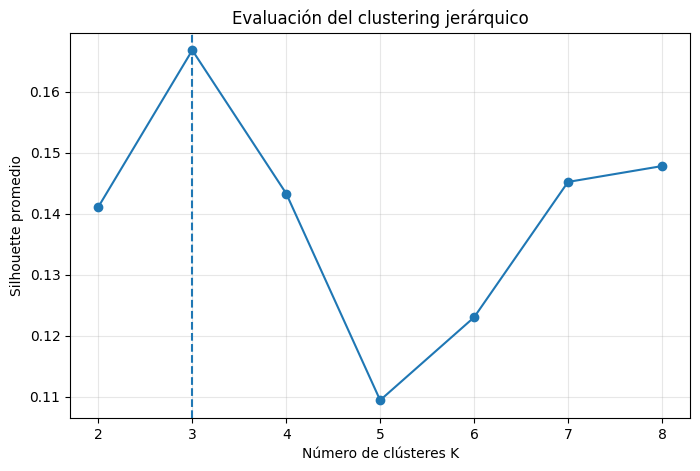


EVALUACIÓN DEL CLUSTERING JERÁRQUICO
Número de registros: 1000
Tipo de distancia: gower
Método de enlace: complete
Valores de K evaluados: 2 a 8
----------------------------------------
Mejor K según Silhouette: 3
Silhouette promedio: 0.1668
Interpretación: Estructura poco definida
----------------------------------------
Correlación cofenética: 0.485
Interpretación: Baja: el dendrograma representa débilmente las distancias originales

TABLA DE EVALUACIÓN:
 k  clusters_obtenidos  silhouette_promedio interpretacion_silhouette  cluster_menor  cluster_mayor                  frecuencia_cluster
 2                   2               0.1411  Estructura poco definida            269            731                            269, 731
 3                   3               0.1668  Estructura poco definida            269            373                       269, 358, 373
 4                   4               0.1433  Estructura poco definida            162            358                  269, 358, 162

In [14]:
evaluacion_CJ = f_evaluacion_clustering_jerarquico(
    modelo=modelo_CJ,
    k_min=2,
    k_max=8,
    graficar=True
)

# Interpretación del caso de estudio

Este caso de estudio cumple con el objetivo planteado de implementar y evaluar un modelo de *clustering* dentro del aprendizaje no supervisados con datos relacionados con el comportamiento de compras de clientes.

El modelo de *Clustering Jerárquico* fue construido con *K=4* grupos, al final el modelo sugiere este resumen de grupos:

* *Clúster 1* con *269* clientes presenciales del sur con satisfacción alta y consumo medio.

* *Clúster 2* con *358* clientes digitales de mayor valor mercial.

* *Clúster 3* con *162* clientes presenciales de baja actividad y baja respuesta promocional.

* *Clúster 4* con *211* clientes presenciales con baja satisfacción pero alta respuesta promocional.

Con respecto a la evaluación del modelo, esta se realizó calculando el estadístico *Silhouette* y la correlación cofenética.

De acuerdo con *Silhouette*, el mejor valor de *K* fue *3*, con un promedio de *0.1668*, lo que indica una estructura poco definida.

La correlación cofenética fue de *0.485*, por lo que se interpreta como: baja: el dendrograma representa débilmente las distancias originales.

Finalmente, se concluye que el modelo no es más adecuado para estos datos, al menos bajo la configuración usada: distancia de *Gower*, método de enlace seleccionado y variables incluidas.

Se puede decir que el *Clustering Jerárquico* no ofrece una estructura de agrupamiento sólida para este conjunto de datos.